In [1]:
import rasterio as rio
from rasterio.merge import merge
from rasterio.windows import Window
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('..')
from utils.imgShow import imsShow

In [2]:
input_dir = '../data/result'                 
output_path = '../data/result/2001_pred_merged.tif'  

file_pattern = os.path.join(input_dir, 'L5_2001_*.tif')
src_files = glob.glob(file_pattern)

src_datasets = [rio.open(fp) for fp in src_files]

mosaic, out_transform = merge(src_datasets, method='max')

out_meta = src_datasets[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform,
})

with rio.open(output_path, "w", **out_meta) as dest:
    dest.write(mosaic)

for src in src_datasets:
    src.close()

print(f"输出文件：{output_path}")

输出文件：../data/result/2001_pred_merged.tif


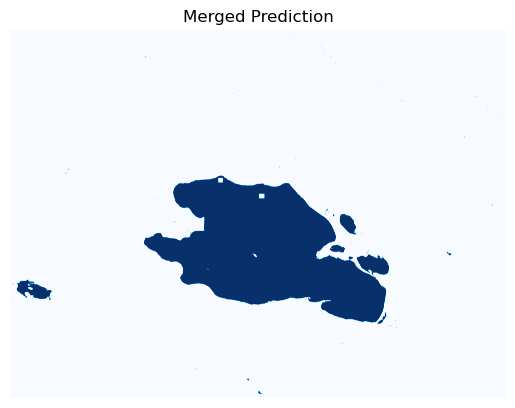

In [3]:
with rio.open(output_path) as src:
    img = src.read(1) 
plt.imshow(img, cmap='Blues')
plt.title("Merged Prediction")
plt.axis('off')
plt.show()

In [4]:
# import geopandas as gpd
# import rasterio
# from rasterio.features import rasterize
# from rasterio.transform import from_origin

# input_gpkg = "../data/truth/qinghai_lake_basin.gpkg"   # 输入矢量文件
# output_tif = "../data/truth/qinghai_lake_basin.tif"    # 输出 TIFF 路径
# pixel_size = 0.001       # 分辨率（单位：度，因坐标系为 WGS84）
# burn_value = 1           # 多边形内填充值
# nodata = 0               # 背景值
# # ====================

# # 读取矢量数据
# gdf = gpd.read_file(input_gpkg)
# print(f"要素数量: {len(gdf)}")
# print(f"坐标系: {gdf.crs}")

# # 获取总边界并计算输出尺寸
# minx, miny, maxx, maxy = gdf.total_bounds
# width = int((maxx - minx) / pixel_size)
# height = int((maxy - miny) / pixel_size)
# print(f"输出尺寸: {width} x {height} 像素")

# # 创建仿射变换（左上角坐标 + 像素大小）
# transform = from_origin(minx, maxy, pixel_size, pixel_size)

# # 准备栅格化数据：几何 + 烧录值
# shapes = ((geom, burn_value) for geom in gdf.geometry)

# # 执行栅格化
# raster = rasterize(
#     shapes,
#     out_shape=(height, width),
#     transform=transform,
#     fill=nodata,
#     dtype='uint8'
# )

# # 写入 GeoTIFF
# with rasterio.open(
#     output_tif, 'w',
#     driver='GTiff',
#     height=height,
#     width=width,
#     count=1,
#     dtype='uint8',
#     crs=gdf.crs,
#     transform=transform,
#     nodata=nodata
# ) as dst:
#     dst.write(raster, 1)

# print(f"转换完成！输出文件：{output_tif}")

In [5]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

input_raster = '../data/result/2001_pred_merged.tif'  # 待裁剪的栅格
mask_raster  = '../data/truth/qinghai_lake_basin.tif'    # 掩膜栅格（值为1的区域保留）
output_raster = '../data/result/2001_pred_masked.tif'    

def align_mask_to_target(mask_path, target_profile):
    """将掩膜重采样到目标栅格的格网（最近邻插值）"""
    with rasterio.open(mask_path) as src:
        mask_aligned = np.zeros((target_profile['height'], target_profile['width']), dtype=np.uint8)
        reproject(
            source=rasterio.band(src, 1),
            destination=mask_aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_profile['transform'],
            dst_crs=target_profile['crs'],
            resampling=Resampling.nearest
        )
        return mask_aligned, src.nodata

with rasterio.open(input_raster) as src_target:
    target_profile = src_target.profile
    target_data = src_target.read()  

    # 检查掩膜是否对齐
    with rasterio.open(mask_raster) as src_mask:
        same_crs = src_target.crs == src_mask.crs
        same_shape = src_target.shape == src_mask.shape
        same_transform = np.allclose(src_target.transform, src_mask.transform, atol=1e-9)

        if same_crs and same_shape and same_transform:
            print("掩膜与目标栅格完全对齐，直接使用原始掩膜。")
            mask = src_mask.read(1)
            mask_nodata = src_mask.nodata
        else:
            print("掩膜与目标栅格不对齐，重采样对齐...")
            mask, mask_nodata = align_mask_to_target(mask_raster, target_profile)

    # 构建有效区域掩膜（值为1的区域）
    if mask_nodata is not None:
        valid_mask = (mask == 1) & (mask != mask_nodata)
    else:
        valid_mask = (mask == 1)

    # 创建输出数组（用目标文件的 nodata 填充）
    out_nodata = target_profile.get('nodata', 0)
    if out_nodata is None:
        out_nodata = 0
    out_image = np.full_like(target_data, out_nodata, dtype=target_profile['dtype'])

    # 应用掩膜：只保留 valid_mask 为 True 的像素
    for band in range(target_data.shape[0]):
        out_image[band][valid_mask] = target_data[band][valid_mask]

    out_profile = target_profile.copy()
    out_profile.update({'nodata': out_nodata})
    with rasterio.open(output_raster, 'w', **out_profile) as dst:
        dst.write(out_image)

print(f"裁剪完成！输出文件：{output_raster}")

掩膜与目标栅格不对齐，重采样对齐...
裁剪完成！输出文件：../data/result/2001_pred_masked.tif


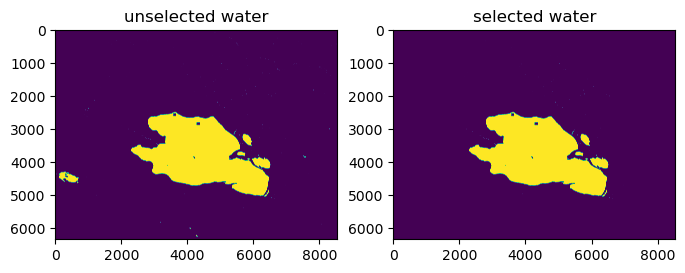

In [6]:

with rio.open(input_raster) as img_src, rio.open(output_raster) as pred_src:
    img_arr = img_src.read(1) 
    pred_arr = pred_src.read(1)  
imsShow([img_arr, pred_arr], ['unselected water', 'selected water'], figsize=(8, 3))

In [7]:
# output_path = '../data/result/2023_07_02_pred_merged.tif'
# with rio.open(output_path) as src:
#     img_arr = src.read(1) 
# print("数组形状:", img_arr.shape)
# print("数据类型:", img_arr.dtype)
# print("值范围:", img_arr.min(), "~", img_arr.max())
# print("左上角 5x5 区域:\n", img_arr[:2, :2])

In [8]:
# output_path = '../data/result/2023_07_02_pred_merged.tif'
# path_output = '../data/result/2023_07_02_pred_masked.tif'
# crop_pixels = 500  

# with rio.open(output_path) as src:
#     img = src.read(1)  
#     height, width = img.shape
    
#     # 创建一个全1的掩膜，然后将四周区域置0
#     mask = np.ones_like(img, dtype=bool)
#     mask[:crop_pixels, :] = False                
#     mask[-crop_pixels:, :] = False               
#     mask[:, :crop_pixels] = False                 
#     mask[:, -crop_pixels:] = False                
    
#     img_masked = np.where(mask, img, 0)
    
#     out_meta = src.meta.copy()
#     with rio.open(path_output, 'w', **out_meta) as dst:
#         dst.write(img_masked, 1)

# print(f"已裁剪四周 {crop_pixels} 像素，结果保存至 {path_output}")

In [9]:
# with rio.open(output_path) as img_src, rio.open(path_output) as pred_src:
#     merge_arr = img_src.read().transpose(1, 2, 0)  # change to channel last format
#     pred_arr = pred_src.read(1)   # read the first band (the classification result)
# imsShow([merge_arr, pred_arr], ['merge image', 'water prediction'], figsize=(8, 3))

In [10]:
# path_img = '../data/scene/2023_07_04.tif'
# path_pred = '../data/result/2023_07_04_pred_merged.tif'
# path_output = '../data/result/2023_07_04_pred_masked.tif'

# win_size = 512

# with rio.open(path_img) as src_img, rio.open(path_pred) as src_pred:
#     assert src_img.shape == src_pred.shape, "图像尺寸不匹配"
#     height, width = src_img.height, src_img.width

#     out_profile = src_pred.profile.copy()
#     out_profile.update(compress='lzw')

#     with rio.open(path_output, 'w', **out_profile) as dst:
#         for i in range(0, height, win_size):
#             for j in range(0, width, win_size):
#                 w = min(win_size, width - j)
#                 h = min(win_size, height - i)
#                 window = Window(j, i, w, h)

#                 img_data = src_img.read(window=window)  # 读取所有波段，形状 (bands, h, w)
#                 condition = np.all(img_data > 0, axis=0)  # 所有波段都大于0的区域为有效
#                 pred_band = src_pred.read(1, window=window)  # 读取预测值波段
               
#                 #有效区域保留原预测值，无效区域设为0
#                 masked_pred = np.where(condition, pred_band, 0)
#                 dst.write(masked_pred, 1, window=window)

#         print(f"处理完成，结果保存至: {path_output}")

In [11]:
# with rio.open(output_path) as img_src, rio.open(path_output) as pred_src:
#     merge_arr = img_src.read().transpose(1, 2, 0)  # change to channel last format
#     pred_arr = pred_src.read(1)   # read the first band (the classification result)
# imsShow([merge_arr, pred_arr], ['merge image', 'water prediction'], figsize=(8, 3))